In [1]:
# Import libraries
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.22f' % x)
import numpy as np
import matplotlib.pyplot as plt
import os
output_dir = 'figs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [2]:
# --- helpers ---
def read_xyce_csv(path):
    return pd.read_csv(path, delimiter=';', comment='#')

def complex_from_cols(df, real_col, imag_col):
    # Vectorized: returns numpy complex array
    return df[real_col].to_numpy() + 1j * df[imag_col].to_numpy()

def mag_phase(z):
    # z: complex numpy array
    return np.abs(z), np.degrees(np.angle(z))

def at_freq(df, freq):
    return df.loc[df["Freq"].eq(freq)].copy()

def power_dbm(I, V, Vph_deg, Iph_deg):
    # Same logic: P = I*V*cos(phiV - phiI), then dBm, then +3
    p_w = I * V * np.cos(np.radians(Vph_deg - Iph_deg))
    return 10 * np.log10(p_w * 1000) + 3

In [3]:
# --- file paths ---
base = "../schematic/compression_1/csv/"
paths = {
    "Iin":  f"{base}/IPR2.csv",
    "Iout": f"{base}/IPR3.csv",
    "Vin":  f"{base}/Vin.csv",
    "Vout": f"{base}/Vout.csv",
}

# --- read CSVs ---
Iin_df  = read_xyce_csv(paths["Iin"])
Iout_df = read_xyce_csv(paths["Iout"])
Vin_df  = read_xyce_csv(paths["Vin"])
Vout_df = read_xyce_csv(paths["Vout"])

# --- build complex signals ---
vin  = complex_from_cols(Vin_df,  "r xyce/V(VIN)",   "i xyce/V(VIN)")
vout = complex_from_cols(Vout_df, "r xyce/V(VOUT)",  "i xyce/V(VOUT)")
iin  = complex_from_cols(Iin_df,  "r xyce/I(PR2)",   "i xyce/I(PR2)")
iout = complex_from_cols(Iout_df, "r xyce/I(PR3)",   "i xyce/I(PR3)")

Vin_mag,  Vin_ph  = mag_phase(vin)
Vout_mag, Vout_ph = mag_phase(vout)
Iin_mag,  Iin_ph  = mag_phase(iin)
Iout_mag, Iout_ph = mag_phase(iout)

# --- assemble dataframe (same fields you had) ---
power_df = pd.DataFrame({
    "Freq": Iin_df["FREQ"],

    "Vin_magnitude":  Vin_mag,
    "Vin_phase":      Vin_ph,
    "Vout_magnitude": Vout_mag,
    "Vout_phase":     Vout_ph,
    "Iin_magnitude":  Iin_mag,
    "Iin_phase":      Iin_ph,
    "Iout_magnitude": Iout_mag,
    "Iout_phase":     Iout_ph,

    "Vin_real": np.real(vin),
    "Vin_imag": np.imag(vin),
    "Iin_real": np.real(iin),
    "Iin_imag": np.imag(iin),
})

# --- filter and compute powers ---
Fref_of_interest = 50e9
df_50_ghz = at_freq(power_df, Fref_of_interest)

RMS = False
scale = (1 / np.sqrt(2)) if RMS else 1.0

Iin  = df_50_ghz["Iin_magnitude"]  * scale
Vin  = df_50_ghz["Vin_magnitude"]  * scale
Iout = df_50_ghz["Iout_magnitude"] * scale
Vout = df_50_ghz["Vout_magnitude"] * scale

df_50_ghz["Output_Power_dbm"]      = power_dbm(Iout, Vout, df_50_ghz["Vout_phase"], df_50_ghz["Iout_phase"])
df_50_ghz["Input_power_calc_dbm"]  = power_dbm(Iin,  Vin,  df_50_ghz["Vin_phase"],  df_50_ghz["Iin_phase"])


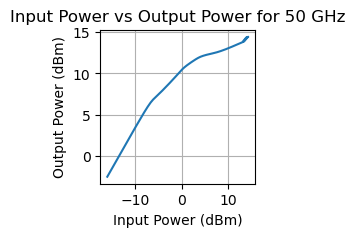

In [4]:
df_50_ghz.plot(
    x="Input_power_calc_dbm",
    y="Output_Power_dbm",
    figsize=(2, 2),
    grid=True,
    legend=False,
    xlabel="Input Power (dBm)",
    ylabel="Output Power (dBm)",
    title="Input Power vs Output Power for 50 GHz"
)
plt.show()


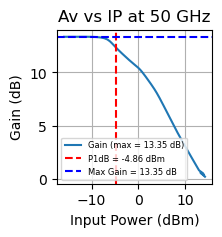

In [6]:
Pi = df_50_ghz["Input_power_calc_dbm"].to_numpy()
Gain_db = (df_50_ghz["Output_Power_dbm"] - df_50_ghz["Input_power_calc_dbm"]).to_numpy()

max_gain = Gain_db.max()

P1db_index = np.argmin(np.abs(max_gain - Gain_db - 1))
Pi_p1db = Pi[P1db_index]

fig, ax = plt.subplots(figsize=(2, 2))

ax.plot(Pi, Gain_db, label=f"Gain (max = {max_gain:.2f} dB)")
ax.axvline(Pi_p1db, color="red", linestyle="--", label=f"P1dB = {Pi_p1db:.2f} dBm")
ax.axhline(max_gain, color="blue", linestyle="--", label=f"Max Gain = {max_gain:.2f} dB")

ax.set(
    xlabel="Input Power (dBm)",
    ylabel="Gain (dB)",
    title="Av vs IP at 50 GHz"
)

ax.grid(True)
ax.legend(fontsize=6)
plt.show()
